# EDA And Preprocessing

## Data Loader

In [1]:
from dataset import CellPaintingDataset
from torch.utils.data import DataLoader

dataset = CellPaintingDataset("../data/plate1", channels=[1,2,3,4,5], tile_size=224)

print("Num fields:", len(dataset.fields))   # ~14 or however many you have
print("Num tiles:", len(dataset))           # fields × 16

x = dataset[0]
print("Shape:", x.shape)        # should be (5, 224, 224)
print("Min:", x.min().item())
print("Max:", x.max().item())

Final valid fields: 160
Num fields: 160
Num tiles: 2328
Shape: torch.Size([5, 224, 224])
Min: 0.0
Max: 1.0


In [2]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch in loader:
    print(batch.shape)
    break

torch.Size([4, 5, 224, 224])


## EDA

Note that:
* Ch1 Mito Mitochondria
* Ch2 AGP Actin, Golgi, Plasma membrane
* Ch3 RNA / Nucleoli
* Ch4 ER Endoplasmic Reticulum
* Ch5 DNA Nucleus (Hoechst 33342)


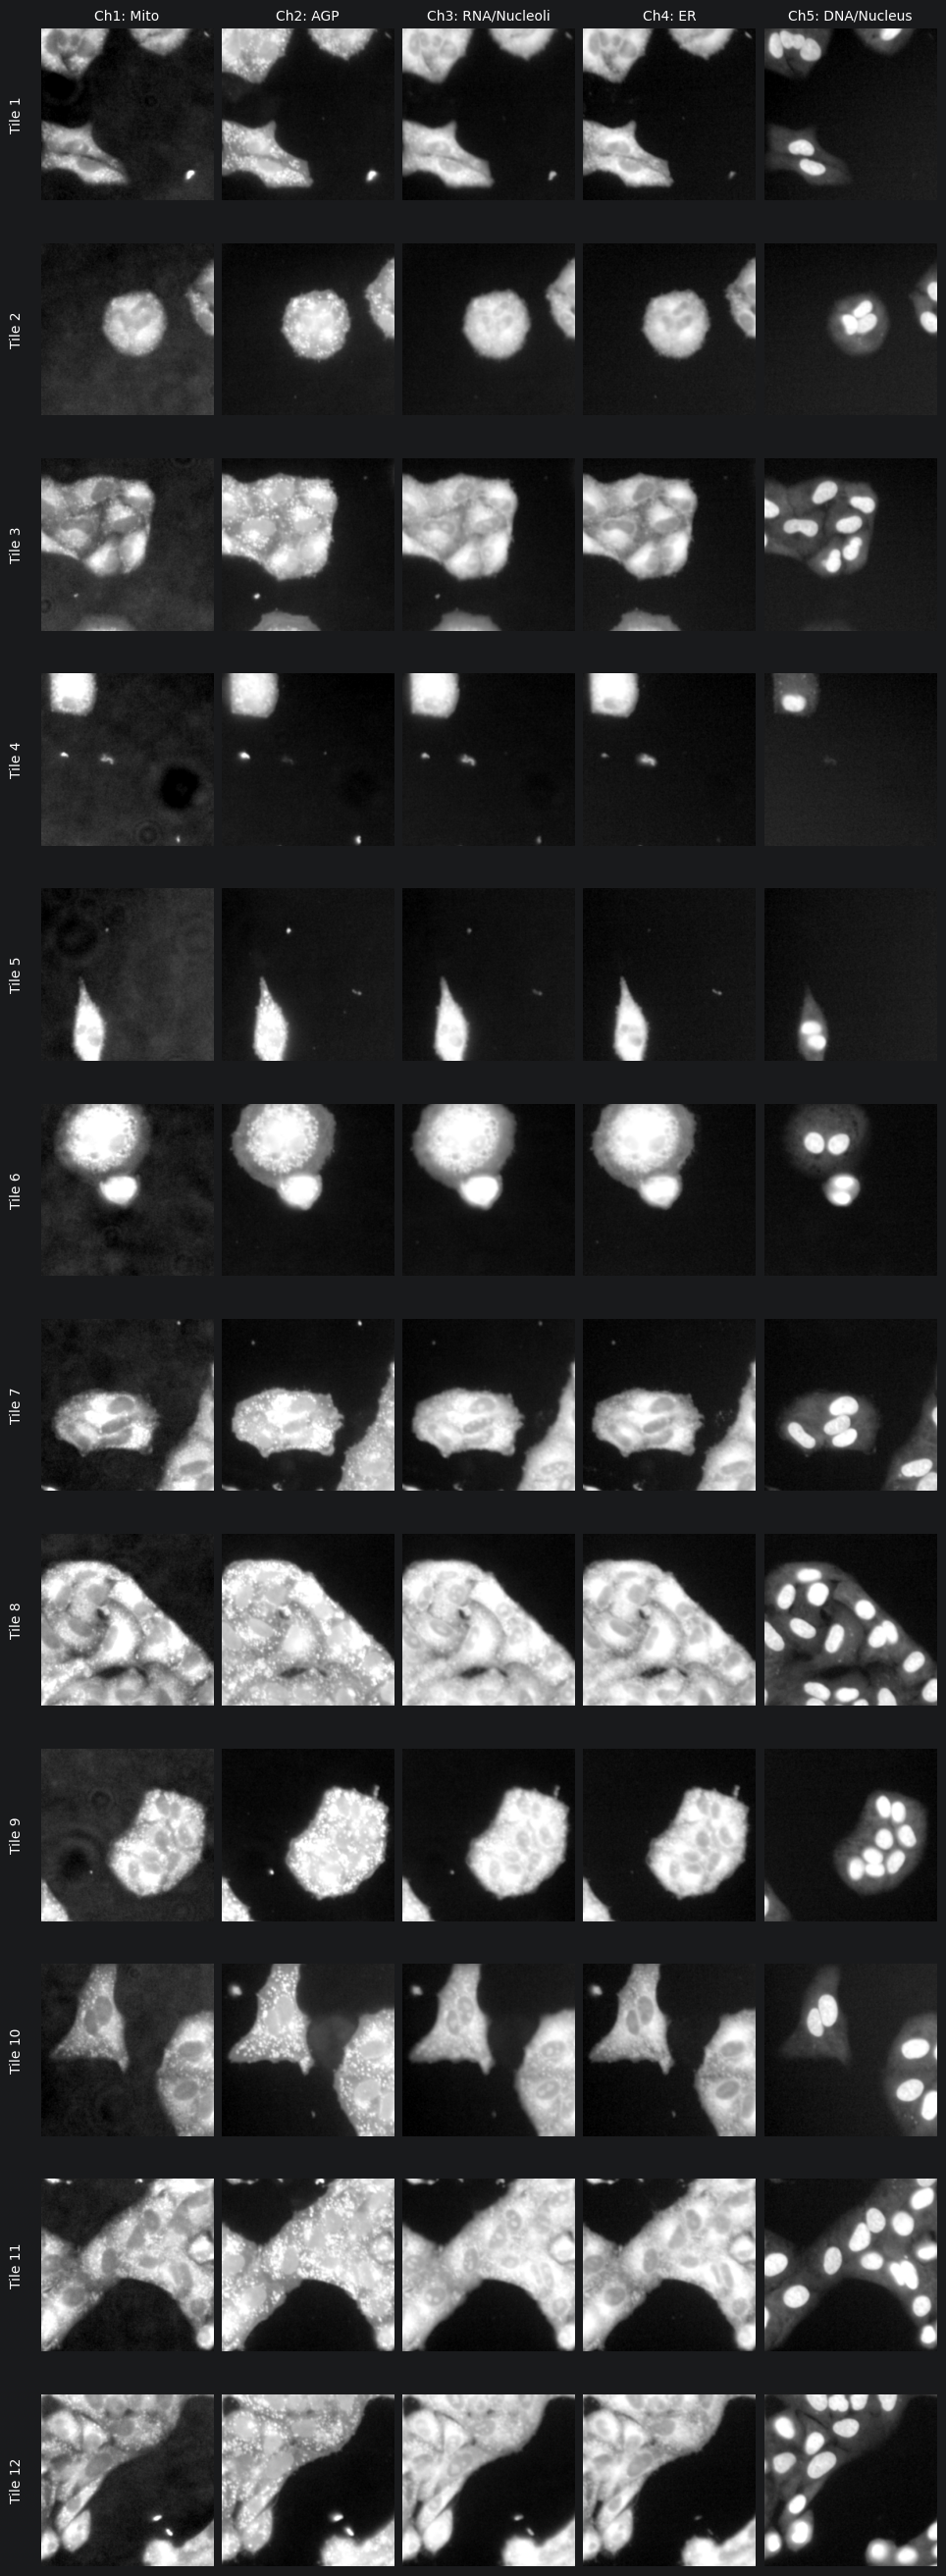

In [3]:
import matplotlib.pyplot as plt

def plot_grid(dataset, n=6, channel_names=None):
    n_channels = len(dataset[0])

    fig, axes = plt.subplots(
        n, n_channels,
        figsize=(2.5 * n_channels, 2.5 * n)
    )

    if channel_names is None:
        channel_names = [f"Channel {c+1}" for c in range(n_channels)]

    for i in range(n):
        x = dataset[i]

        for c in range(n_channels):
            ax = axes[i, c]
            ax.imshow(x[c], cmap="gray")
            ax.set_axis_off()

            if i == 0:
                ax.set_title(channel_names[c], fontsize=10)

        # row labels (attach to first column axis)
        axes[i, 0].text(
            -0.1, 0.5,
            f"Tile {i+1}",
            rotation=90,
            transform=axes[i, 0].transAxes,
            va="center",
            ha="right",
            fontsize=10
        )

    fig.subplots_adjust(
        left=0.25,
        right=0.98,
        top=0.92,
        bottom=0.05,
        wspace=0.05,
        hspace=0.1
    )

    plt.show()

channels = ["Ch1: Mito", "Ch2: AGP", "Ch3: RNA/Nucleoli", "Ch4: ER", "Ch5: DNA/Nucleus"]

plot_grid(dataset, n=12, channel_names=channels)

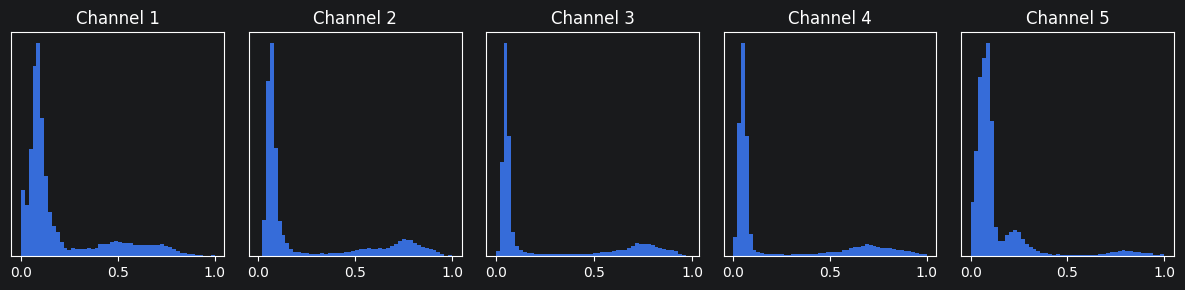

In [4]:
# Intensity distributions to check for normalization and corruption
import numpy as np

def plot_intensity_histograms(x):
    plt.figure(figsize=(12, 3))

    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.hist(x[i].flatten(), bins=50)
        plt.title(f"Channel {i+1}")
        plt.xticks([0, 0.5, 1])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

plot_intensity_histograms(x)

100%|██████████| 2328/2328 [00:32<00:00, 72.35it/s] 


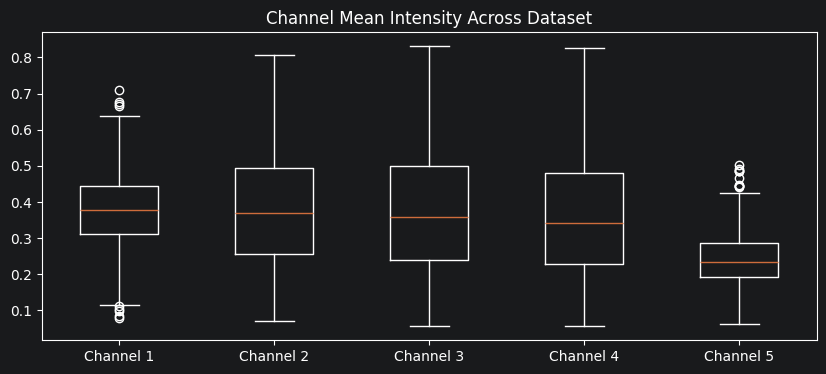

In [5]:
from tqdm import tqdm

# Dataset-wide channel statistics
means = []
stds = []

for i in tqdm(range(len(dataset))):
    x = dataset[i]
    means.append(x.mean(axis=(1,2)))
    stds.append(x.std(axis=(1,2)))

means = np.stack(means)
stds = np.stack(stds)

plt.figure(figsize=(10,4))
plt.title("Channel Mean Intensity Across Dataset")
plt.boxplot(means)
plt.xticks(range(1,6), [f"Channel {i}" for i in range(1,6)])
plt.show()